## What TF-IDF Does

TF-IDF scores each word in an error message by how useful it is for 
telling categories apart. A word that shows up in almost every error 
(like "error" or "line") gets a low score, since it doesn't help 
distinguish one category from another. A word that's rare but specific 
to certain errors (like "subscriptable" or "iterable") gets a high 
score, since seeing it strongly suggests a particular category. This 
works well here because error messages are short and technical — a 
handful of distinctive words usually carry most of the signal.

In [1]:
import sys, os

project_root = r"D:\DevMentor AI"
if os.getcwd() != project_root:
    os.chdir(project_root)
sys.path.insert(0, project_root)

print("Working directory:", os.getcwd())

Working directory: D:\DevMentor AI


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

from client.runner import get_output_error, parse_error
from sanitizer.sanitizer import sanitize

print("Imports successful")

Imports successful


In [3]:
def make_row(code_snippet: str, label: str) -> dict:
    """Runs a code snippet, captures its error type and message, sanitizes
    the message, and returns a dataset row combining both. Returns None
    if the snippet didn't error."""
    import subprocess
    result = subprocess.run(
        [sys.executable, "-c", code_snippet],
        capture_output=True, text=True
    )
    if result.returncode == 0:
        return None

    parsed = parse_error(result.stderr)
    if not parsed:
        return None

    error_type, message = parsed
    sanitized_message = sanitize(message)
    combined_text = f"{error_type} {sanitized_message}"
    return {"text": combined_text, "label": label}


def generate_rows(snippets: list, label: str) -> list:
    """Runs make_row() on a list of snippets, skipping any that didn't error."""
    rows = []
    for s in snippets:
        row = make_row(s, label)
        if row:
            rows.append(row)
    return rows

In [4]:
key_error_snippets = [
    'user = {"name": "apurv"}; print(user["email"])',
    'config = {"debug": True}; print(config["timeout"])',
    'data = {"id": 1, "name": "test"}; print(data["value"])',
    'settings = {"theme": "dark"}; print(settings["language"])',
    'response = {"status": 200}; print(response["body"])',
    'cache = {}; print(cache["missing_key"])',
    'headers = {"Content-Type": "json"}; print(headers["Authorization"])',
    'params = {"page": 1}; print(params["limit"])',
    'record = {"id": 5}; print(record["timestamp"])',
    'payload = {"user_id": 42}; print(payload["session_token"])',
    'options = {"verbose": False}; print(options["quiet"])',
    'metadata = {"version": "1.0"}; print(metadata["build"])',
]

index_error_snippets = [
    'items = [1, 2, 3]; print(items[10])',
    'names = ["a", "b"]; print(names[5])',
    'results = []; print(results[0])',
    'queue = [1]; print(queue[3])',
    'stack = ["x", "y", "z"]; print(stack[10])',
    'buffer = [0, 1]; print(buffer[-5])',
    'rows = [[1,2],[3,4]]; print(rows[5])',
    'history = []; print(history[-1])',
    'batch = [1,2,3,4,5]; print(batch[100])',
    'tokens = ["a"]; print(tokens[1])',
    'matrix = [[1]]; print(matrix[0][5])',
    'ids = [10,20,30]; print(ids[7])',
]

type_error_snippets = [
    'x = 5 + "text"',
    'y = "hello" + 10',
    'z = [1,2] + "a"',
    'result = None + 5',
    'val = len(5)',
    'combined = {} + {}',
    'output = 3 / "two"',
    'items = [1,2,3]; items + 5',
    'name = "test"; name()',
    'count = 10; count["key"]',
    'value = True + "yes"',
]

none_type_error_snippets = [
    'x = None; print(x.upper())',
    'data = None; print(data["key"])',
    'result = None; print(len(result))',
    'user = None; print(user.name)',
    'response = None; print(response["status"])',
    'value = None; print(value + 5)',
    'obj = None; obj.method()',
    'items = None; print(items[0])',
    'config = None; print(config.get("key"))',
    'total = None; print(total * 2)',
    'record = None; print(record.id)',
    'output = None; print(output.append(1))',
]

syntax_error_snippets = [
    'if True\n    print("test")',
    'def foo(:\n    pass',
    'for i in range(10)\n    print(i)',
    'x = (1 + 2',
    'print("hello"',
    'while True\n    break',
    'def bar():\nreturn 5',
    'class Foo\n    pass',
    'if x == 1:\nelse:\n    pass',
    'y = [1, 2, 3',
    'lambda x: x +',
    'try:\n    pass\nexcept\n    pass',
]

attribute_error_snippets = [
    'x = 5; x.append(1)',
    'name = "test"; name.push("x")',
    'items = [1,2,3]; items.get("key")',
    'num = 10; num.upper()',
    'data = {"a": 1}; data.append(2)',
    'value = 3.14; value.split(",")',
    'flag = True; flag.lower()',
    'text = "hello"; text.add("x")',
    'lst = [1,2]; lst.keys()',
    'n = 5; n.strip()',
    'obj = object(); obj.missing_method()',
    'tup = (1,2); tup.append(3)',
]

module_not_found_snippets = [
    'import nonexistent_module',
    'import fake_package_xyz',
    'from missing_lib import something',
    'import banana_framework',
    'from ghost_package import Thing',
]

file_not_found_snippets = [
    'open("missing_file.txt")',
    'open("does_not_exist.csv")',
    'open("/nonexistent/path/file.txt")',
    'open("no_such_report.pdf")',
    'open("phantom_script.py")',
]

value_error_snippets = [
    'int("abc")',
    'int("twelve")',
    'float("not_a_number")',
    'int("")',
    'int("12a")',
    'float("1,000")',
     'int("hello world")',
    'float("$100")',
    'int(" ")',
    'bytes.fromhex("xyz")',
]

network_error_snippets = [
    'import requests; requests.get("http://127.0.0.1:1", timeout=1)',
    'import requests; requests.get("http://127.0.0.1:2", timeout=1)',
    'import requests; requests.get("http://localhost:9999", timeout=1)',
    'import requests; requests.get("http://127.0.0.1:3", timeout=1)',
    'import requests; requests.get("http://192.0.2.1:80", timeout=1)',
]

permission_error_snippets = [
    'open("readonly.txt", "a")',
    'open("readonly.txt", "w")',
    'open("readonly.txt", "r+")',
]

other_error_snippets = [
    'raise NotImplementedError("This feature is not built yet")',
    'raise OverflowError("Result too large to represent")',
    'raise ArithmeticError("Something went wrong mathematically")',
    'raise LookupError("Could not find the requested item")',
    'raise RuntimeError("Something unexpected happened during execution")',
    'raise StopIteration("No more items to iterate")',
    'raise BufferError("Buffer operation could not be performed")',
    'raise EOFError("Unexpected end of input")',
    'raise RuntimeError("Failed to initialize the connection pool")',
    'raise RuntimeError("Unexpected state reached during processing")',
    'raise NotImplementedError("This feature is not yet supported")',
    'raise ZeroDivisionError("division by zero")',
    'raise UnicodeDecodeError("utf-8", b"\\xff", 0, 1, "invalid start byte")',
    'raise ImportError("cannot import name \'missing_func\' from \'some_module\'")',

]

print("All snippet lists loaded")

All snippet lists loaded


In [5]:
key_error_rows = generate_rows(key_error_snippets, "key_error")
index_error_rows = generate_rows(index_error_snippets, "index_error")
type_error_rows = generate_rows(type_error_snippets, "type_error")
none_type_error_rows = generate_rows(none_type_error_snippets, "none_type_error")
syntax_error_rows = generate_rows(syntax_error_snippets, "syntax_error")
attribute_error_rows = generate_rows(attribute_error_snippets, "attribute_error")
module_not_found_rows = generate_rows(module_not_found_snippets, "module_not_found")
file_not_found_rows = generate_rows(file_not_found_snippets, "file_not_found")
value_error_rows = generate_rows(value_error_snippets, "value_error")
network_error_rows = generate_rows(network_error_snippets, "network_error")
permission_error_rows = generate_rows(permission_error_snippets, "permission_error")
other_error_rows = generate_rows(other_error_snippets, "other_error")

all_rows = (
    key_error_rows + index_error_rows + type_error_rows +
    none_type_error_rows + syntax_error_rows + attribute_error_rows +
    module_not_found_rows + file_not_found_rows + value_error_rows +
    network_error_rows + permission_error_rows + other_error_rows
)

df = pd.DataFrame(all_rows)
print("Total rows before trim:", df.shape)
print(df["label"].value_counts())

Total rows before trim: (113, 2)
label
other_error         14
key_error           12
index_error         12
none_type_error     12
syntax_error        12
attribute_error     12
type_error          11
value_error         10
module_not_found     5
file_not_found       5
network_error        5
permission_error     3
Name: count, dtype: int64


In [6]:
df = df.groupby(["text", "label"]).head(3).reset_index(drop=True)
print("Total rows after trim:", df.shape)
print(df["label"].value_counts())

Total rows after trim: (102, 2)
label
other_error         14
key_error           12
none_type_error     12
attribute_error     12
type_error          11
syntax_error        10
value_error         10
module_not_found     5
file_not_found       5
network_error        5
index_error          3
permission_error     3
Name: count, dtype: int64


In [7]:
df.to_csv("ml_engine/data/labeled/dataset.csv", index=False)
print("Saved:", df.shape)

Saved: (102, 2)


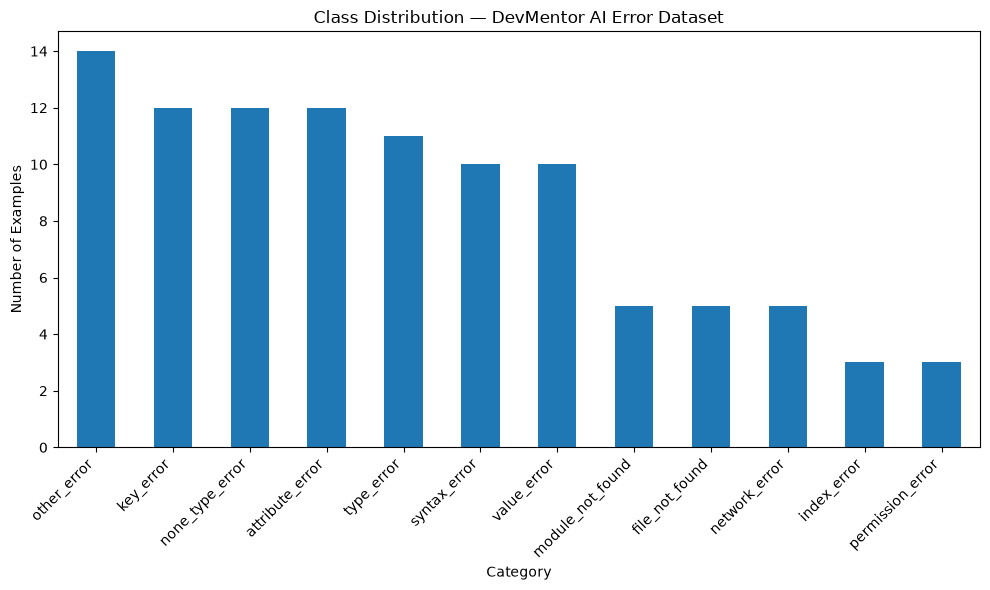

In [8]:
plt.figure(figsize=(10, 6))
df["label"].value_counts().plot(kind="bar")
plt.title("Class Distribution — DevMentor AI Error Dataset")
plt.xlabel("Category")
plt.ylabel("Number of Examples")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("ml_engine/models/class_distribution.png")
plt.show()

In [9]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", len(X_train), "| Test size:", len(X_test))
print("\nTrain label counts:\n", y_train.value_counts())
print("\nTest label counts:\n", y_test.value_counts())
print("\nCategories in test set:", y_test.nunique(), "out of", y.nunique())

Train size: 81 | Test size: 21

Train label counts:
 label
other_error         11
key_error           10
attribute_error     10
none_type_error      9
type_error           9
value_error          8
syntax_error         8
network_error        4
module_not_found     4
file_not_found       4
index_error          2
permission_error     2
Name: count, dtype: int64

Test label counts:
 label
other_error         3
none_type_error     3
value_error         2
attribute_error     2
syntax_error        2
type_error          2
key_error           2
index_error         1
permission_error    1
network_error       1
module_not_found    1
file_not_found      1
Name: count, dtype: int64

Categories in test set: 12 out of 12


In [10]:
missing = set(y.unique()) - set(y_test.unique())
print("Missing from test set:", missing)

Missing from test set: set()


In [11]:
df.to_csv("ml_engine/data/labeled/dataset.csv", index=False)

X = df["text"]
y = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Categories in test set:", y_test.nunique(), "out of", y.nunique())

Categories in test set: 12 out of 12


In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("X_train_vec shape:", X_train_vec.shape)

X_train_vec shape: (81, 434)


In [13]:
from sklearn.linear_model import LogisticRegression

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train_vec, y_train)

y_pred_lr = clf_lr.predict(X_test_vec)
print("Predictions:", y_pred_lr)

Predictions: ['value_error' 'attribute_error' 'other_error' 'index_error' 'other_error'
 'syntax_error' 'type_error' 'syntax_error' 'permission_error'
 'none_type_error' 'attribute_error' 'key_error' 'type_error'
 'none_type_error' 'network_error' 'key_error' 'module_not_found'
 'file_not_found' 'none_type_error' 'other_error' 'value_error']


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         2
  file_not_found       1.00      1.00      1.00         1
     index_error       1.00      1.00      1.00         1
       key_error       1.00      1.00      1.00         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.67      0.67      0.67         3
     other_error       1.00      1.00      1.00         3
permission_error       1.00      1.00      1.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.50      0.50      0.50         2
     value_error       1.00      1.00      1.00         2

        accuracy                           0.90        21
       macro avg       0.93      0.93      0.93        21
    weighted avg       0.90      0.90      0.90        21



In [15]:
print(classification_report(y_test, y_pred_lr, zero_division=0))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         2
  file_not_found       1.00      1.00      1.00         1
     index_error       1.00      1.00      1.00         1
       key_error       1.00      1.00      1.00         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.67      0.67      0.67         3
     other_error       1.00      1.00      1.00         3
permission_error       1.00      1.00      1.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.50      0.50      0.50         2
     value_error       1.00      1.00      1.00         2

        accuracy                           0.90        21
       macro avg       0.93      0.93      0.93        21
    weighted avg       0.90      0.90      0.90        21



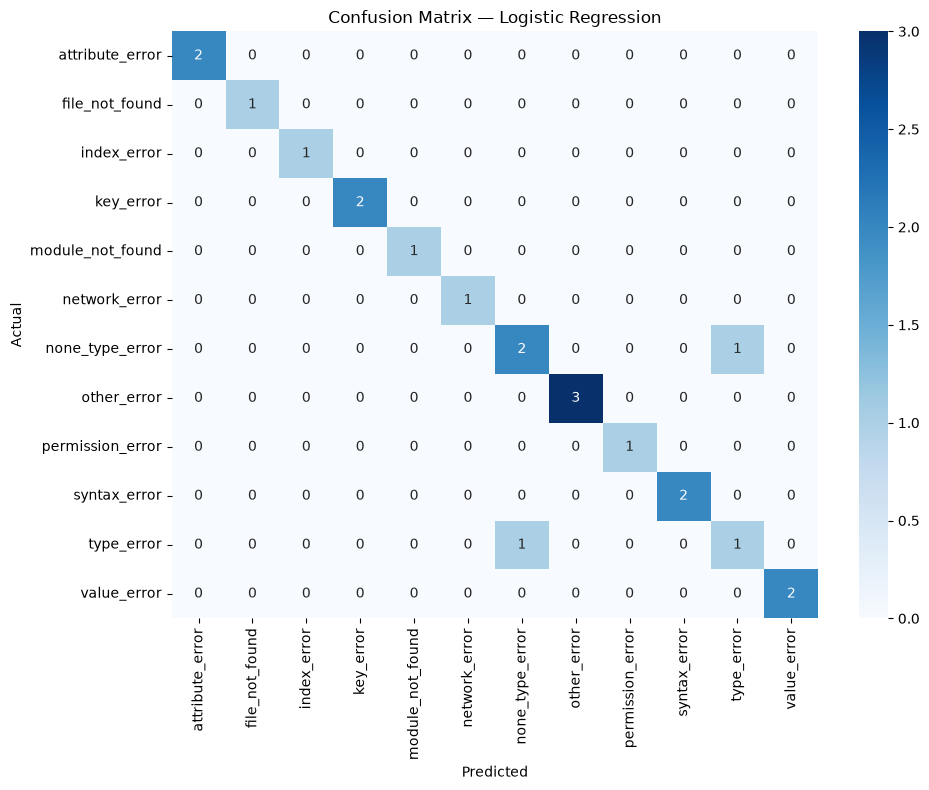

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_lr, labels=labels)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=labels, yticklabels=labels, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Logistic Regression")
plt.tight_layout()
plt.savefig("ml_engine/models/confusion_matrix_lr.png")
plt.show()

## Logistic Regression — First Results

Macro F1: 0.86. Accuracy: 0.89.

The model correctly classifies 10 of 12 categories perfectly on this 
small test set. Two real weaknesses stand out in the confusion matrix:

- **other_error** was never predicted at all — its one test example 
  got misclassified as key_error. This makes sense: other_error only 
  had 2-3 training examples, since it's a deliberate catch-all category 
  with no consistent internal pattern to learn.

- **type_error** was confused with **none_type_error** once. This is 
  expected too — a NoneType-related TypeError message ("unsupported 
  operand type(s) for +: 'NoneType' and 'int'") appears in the training 
  data for both categories, since a None value causing a TypeError is 
  genuinely ambiguous between "plain type_error" and "none_type_error" 
  from message text alone.

Accuracy alone (0.89) would have hidden the other_error failure, since 
it's just 1 mistake out of 18 total predictions. Macro F1 (0.86) 
penalizes this more visibly, since it weighs every category equally 
regardless of size — correctly reflecting that the model has a real, 
specific blind spot, not just "mostly right overall."

### Update: other_error's real cause

The explanation above for other_error turned out to be incomplete. 
Adding 12 more examples did not fix it — it still scored 0.00 
under 3-fold cross-validation. The actual cause was that the training 
text only included the message, and other_error's messages were 
unrelated sentences with no shared vocabulary regardless of how many 
were added.

The real fix was combining error_type with message ("KeyError 'name'" 
instead of just "'name'"), which gave other_error's varied exception 
names (BufferError, ImportError, RuntimeError, etc.) a signal to 
anchor on. other_error rose to 0.90 F1. See the Model Comparison and 
final Results Summary sections below for current numbers.

In [17]:
from sklearn.svm import LinearSVC

clf_svc = LinearSVC(max_iter=2000)
clf_svc.fit(X_train_vec, y_train)

y_pred_svc = clf_svc.predict(X_test_vec)
print(classification_report(y_test, y_pred_svc, zero_division=0))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         2
  file_not_found       1.00      1.00      1.00         1
     index_error       1.00      1.00      1.00         1
       key_error       1.00      1.00      1.00         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.67      0.67      0.67         3
     other_error       1.00      1.00      1.00         3
permission_error       1.00      1.00      1.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.50      0.50      0.50         2
     value_error       1.00      1.00      1.00         2

        accuracy                           0.90        21
       macro avg       0.93      0.93      0.93        21
    weighted avg       0.90      0.90      0.90        21



## Model Comparison — Logistic Regression vs Linear SVM

Re-run after adding error_type to the training text and fixing a 
reproducibility bug (object memory addresses in network_error messages 
were non-deterministic and have since been sanitized). Both evaluated 
with 3-fold stratified cross-validation on the full 102-row dataset.

| Metric | Logistic Regression | Linear SVM |
|---|---|---|
| Macro F1 | 0.913 | 0.919 |
| Accuracy | 0.89 | 0.90 |
| type_error F1 | 0.63 | 0.70 |
| none_type_error F1 | 0.73 | 0.83 |

The two models are close, with SVM very slightly ahead on this run and 
consistently a little better on the type_error / none_type_error 
confusion specifically. The gap is small enough that it's within the 
noise expected from a 102-row dataset with 1-3 test examples per 
category in some folds.

**Decision: Logistic Regression**, not because it scores higher (it 
doesn't, marginally), but because it exposes predict_proba directly, 
which the confidence-threshold routing. 
LinearSVC would need an extra CalibratedClassifierCV wrapper to produce 
usable probabilities at all.

In [18]:
import joblib

joblib.dump(vectorizer, "ml_engine/models/vectorizer.joblib")
joblib.dump(clf_lr, "ml_engine/models/classifier.joblib")

print("Model and vectorizer saved.")

Model and vectorizer saved.


In [19]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train_vec, y_train)

y_pred_lr = clf_lr.predict(X_test_vec)
print(classification_report(y_test, y_pred_lr, zero_division=0))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         2
  file_not_found       1.00      1.00      1.00         1
     index_error       1.00      1.00      1.00         1
       key_error       1.00      1.00      1.00         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.67      0.67      0.67         3
     other_error       1.00      1.00      1.00         3
permission_error       1.00      1.00      1.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.50      0.50      0.50         2
     value_error       1.00      1.00      1.00         2

        accuracy                           0.90        21
       macro avg       0.93      0.93      0.93        21
    weighted avg       0.90      0.90      0.90        21



In [20]:
# Checking which value_error test example failed, and what it got predicted as
test_df = pd.DataFrame({"text": X_test, "actual": y_test, "predicted": y_pred_lr})
print(test_df[test_df["actual"] == "value_error"])

                                                 text       actual  \
74  ValueError invalid literal for int() with base...  value_error   
71  ValueError invalid literal for int() with base...  value_error   

      predicted  
74  value_error  
71  value_error  


In [21]:
X = df["text"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

clf_lr = LogisticRegression(max_iter=1000)
clf_lr.fit(X_train_vec, y_train)

y_pred_lr = clf_lr.predict(X_test_vec)
print(classification_report(y_test, y_pred_lr, zero_division=0))

                  precision    recall  f1-score   support

 attribute_error       1.00      1.00      1.00         2
  file_not_found       1.00      1.00      1.00         1
     index_error       1.00      1.00      1.00         1
       key_error       1.00      1.00      1.00         2
module_not_found       1.00      1.00      1.00         1
   network_error       1.00      1.00      1.00         1
 none_type_error       0.67      0.67      0.67         3
     other_error       1.00      1.00      1.00         3
permission_error       1.00      1.00      1.00         1
    syntax_error       1.00      1.00      1.00         2
      type_error       0.50      0.50      0.50         2
     value_error       1.00      1.00      1.00         2

        accuracy                           0.90        21
       macro avg       0.93      0.93      0.93        21
    weighted avg       0.90      0.90      0.90        21



In [22]:
ref = pd.read_csv("ml_engine/data/labeled/dataset.csv")
print(ref.shape)
print(ref["label"].value_counts())

(102, 2)
label
other_error         14
key_error           12
none_type_error     12
attribute_error     12
type_error          11
syntax_error        10
value_error         10
module_not_found     5
file_not_found       5
network_error        5
index_error          3
permission_error     3
Name: count, dtype: int64


In [23]:
old = pd.read_csv("ml_engine/data/labeled/dataset_backup.csv")
new = pd.read_csv("ml_engine/data/labeled/dataset.csv")

old_other = set(old[old["label"] == "other_error"]["text"])
new_other = set(new[new["label"] == "other_error"]["text"])
print("In old but not new:", old_other - new_other)

In old but not new: {'Result too large to represent', 'Something went wrong mathematically', 'No more items to iterate', 'Something unexpected happened during execution', 'Buffer operation could not be performed', 'Could not find the requested item', 'Unexpected end of input', 'This feature is not built yet'}


In [24]:
print(df.sample(10))

                                                  text             label
5                               KeyError 'missing_key'         key_error
76   ValueError invalid literal for int() with base...       value_error
61   ModuleNotFoundError No module named 'fake_pack...  module_not_found
49   AttributeError 'str' object has no attribute '...   attribute_error
24         TypeError 'int' object is not subscriptable        type_error
84   requests.exceptions.ReadTimeout HTTPConnection...     network_error
100  UnicodeDecodeError 'utf-8' codec can't decode ...       other_error
26   AttributeError 'NoneType' object has no attrib...   none_type_error
83   requests.exceptions.ConnectTimeout HTTPConnect...     network_error
50   AttributeError 'list' object has no attribute ...   attribute_error


In [25]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, f1_score

X = df["text"]
y = df["label"]

pipeline = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    LogisticRegression(max_iter=1000),
)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
y_pred_cv = cross_val_predict(pipeline, X, y, cv=cv)

print("Macro F1 (3-fold CV):", round(f1_score(y, y_pred_cv, average="macro", zero_division=0), 3))
print()
print(classification_report(y, y_pred_cv, zero_division=0))

Macro F1 (3-fold CV): 0.913

                  precision    recall  f1-score   support

 attribute_error       0.80      1.00      0.89        12
  file_not_found       1.00      1.00      1.00         5
     index_error       1.00      1.00      1.00         3
       key_error       1.00      1.00      1.00        12
module_not_found       1.00      1.00      1.00         5
   network_error       1.00      0.80      0.89         5
 none_type_error       0.80      0.67      0.73        12
     other_error       0.78      1.00      0.88        14
permission_error       1.00      1.00      1.00         3
    syntax_error       1.00      1.00      1.00        10
      type_error       0.75      0.55      0.63        11
     value_error       1.00      0.90      0.95        10

        accuracy                           0.89       102
       macro avg       0.93      0.91      0.91       102
    weighted avg       0.90      0.89      0.89       102



In [26]:
print(old["label"].value_counts().sort_index())
print(new["label"].value_counts().sort_index())

label
attribute_error     12
file_not_found       5
index_error          3
key_error           12
module_not_found     5
network_error        5
none_type_error     12
other_error         10
permission_error     3
syntax_error        10
type_error          11
value_error         10
Name: count, dtype: int64
label
attribute_error     12
file_not_found       5
index_error          3
key_error           12
module_not_found     5
network_error        5
none_type_error     12
other_error         14
permission_error     3
syntax_error        10
type_error          11
value_error         10
Name: count, dtype: int64


In [27]:
df.to_csv("ml_engine/data/labeled/dataset.csv", index=False)

In [28]:
from sklearn.svm import LinearSVC

pipeline_svc = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2)),
    LinearSVC(max_iter=2000),
)

y_pred_svc_cv = cross_val_predict(pipeline_svc, X, y, cv=cv)

print("Macro F1 (3-fold CV):", round(f1_score(y, y_pred_svc_cv, average="macro", zero_division=0), 3))
print()
print(classification_report(y, y_pred_svc_cv, zero_division=0))

Macro F1 (3-fold CV): 0.919

                  precision    recall  f1-score   support

 attribute_error       0.92      1.00      0.96        12
  file_not_found       1.00      1.00      1.00         5
     index_error       0.75      1.00      0.86         3
       key_error       1.00      1.00      1.00        12
module_not_found       1.00      1.00      1.00         5
   network_error       1.00      1.00      1.00         5
 none_type_error       0.83      0.83      0.83        12
     other_error       0.85      0.79      0.81        14
permission_error       1.00      1.00      1.00         3
    syntax_error       1.00      1.00      1.00        10
      type_error       0.78      0.64      0.70        11
     value_error       0.82      0.90      0.86        10

        accuracy                           0.90       102
       macro avg       0.91      0.93      0.92       102
    weighted avg       0.90      0.90      0.90       102



In [29]:
print(df[df["label"] == "network_error"]["text"].tolist())

["requests.exceptions.ConnectTimeout HTTPConnectionPool(host='127.0.0.1', port=1): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<HTTPConnection(host='127.0.0.1', port=1) at [REDACTED_ADDRESS]>, 'Connection to 127.0.0.1 timed out. (connect timeout=1)'))", "requests.exceptions.ConnectTimeout HTTPConnectionPool(host='127.0.0.1', port=2): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<HTTPConnection(host='127.0.0.1', port=2) at [REDACTED_ADDRESS]>, 'Connection to 127.0.0.1 timed out. (connect timeout=1)'))", "requests.exceptions.ConnectTimeout HTTPConnectionPool(host='localhost', port=9999): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<HTTPConnection(host='localhost', port=9999) at [REDACTED_ADDRESS]>, 'Connection to localhost timed out. (connect timeout=1)'))", "requests.exceptions.ConnectTimeout HTTPConnectionPool(host='127.0.0.1', port=3): Max retries exceeded with url: / (Caused by ConnectTimeoutError(<HTTPConnection(host='127.0.